# Simple Regression Example

In the classification notebook, we trained a neural network to separate classes in a transformed feature space. Now we use a similar network for **regression**: estimating a continuous value from input features.

We will approximate the function $y = x_1^2 + x_2^2$ from noisy training samples — a simple problem where we can visualize both the true surface and the network's predictions.

## 1. Create and visualize the dataset

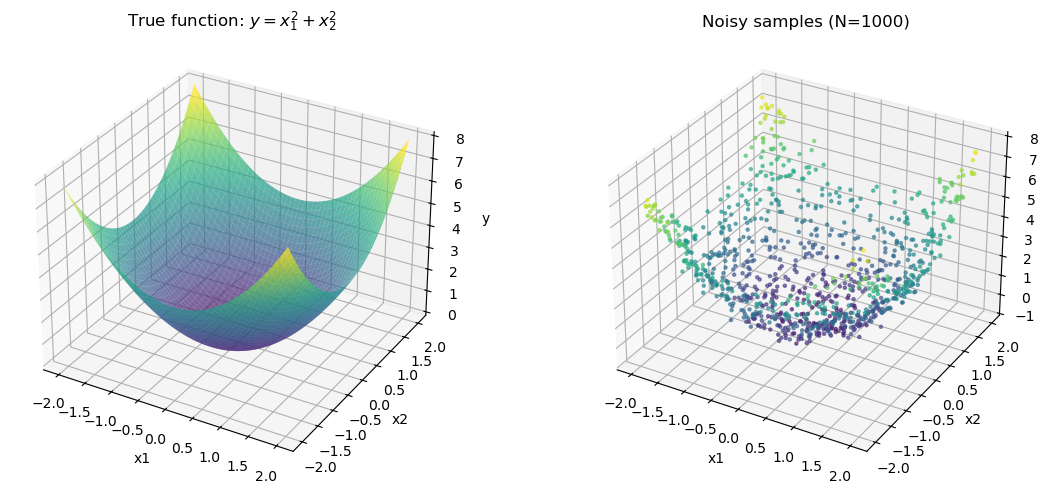

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# Generate 2D input samples uniformly in [-2, 2] x [-2, 2]
N = 1000
X = np.random.uniform(-2, 2, size=(N, 2))

# True function: y = x1^2 + x2^2, with some noise
Y = X[:, 0]**2 + X[:, 1]**2 + 0.3 * np.random.randn(N)

# Visualize the true function as a surface and the noisy samples
fig = plt.figure(figsize=(12, 5))

# Left: true surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
grid = np.linspace(-2, 2, 50)
X1g, X2g = np.meshgrid(grid, grid)
Yg = X1g**2 + X2g**2
ax1.plot_surface(X1g, X2g, Yg, cmap='viridis', alpha=0.7)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('y')
ax1.set_title('True function: $y = x_1^2 + x_2^2$')

# Right: noisy samples
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X[:, 0], X[:, 1], Y, c=Y, cmap='viridis', s=5, alpha=0.6)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('y')
ax2.set_title(f'Noisy samples (N={N})')

plt.tight_layout()
plt.show()

## 2. Split into training and test sets

In [2]:
# Shuffle and split 50/50, as in the classification notebook
from numpy.random import permutation

perm = permutation(N)
X, Y = X[perm], Y[perm]

half = N // 2
X_train, Y_train = X[:half], Y[:half]
X_test,  Y_test  = X[half:], Y[half:]

print(f"Training: {len(X_train)} samples")
print(f"Test:     {len(X_test)} samples")

Training: 500 samples
Test:     500 samples


## 3. Build the neural network

We use a simple network with two hidden layers. Note the differences from the classification network:

- The **output layer has one neuron** (a single continuous value), with **no activation function** (linear output).
- The **loss function** is `MSELoss` (mean squared error) instead of `CrossEntropyLoss`.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class RegressionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)   # linear output for regression
        )

    def forward(self, x):
        return self.layers(x)

model = RegressionNet()
print(model)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

RegressionNet(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 4. Train the model

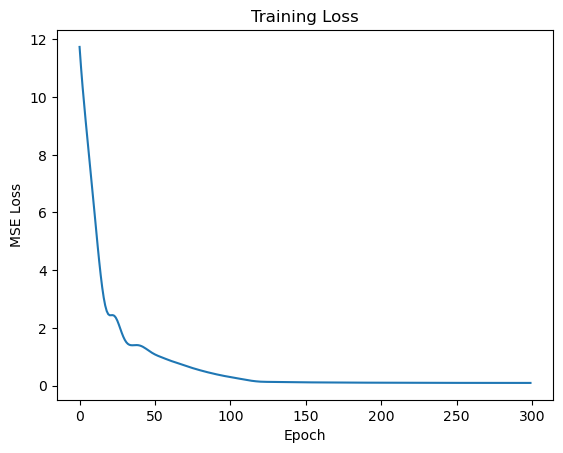

Final training loss: 0.0902


In [4]:
# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
Y_train_t = torch.FloatTensor(Y_train).unsqueeze(1)  # shape (N, 1)

# Training loop
model.train()
epochs = 300
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, Y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.show()

print(f"Final training loss: {losses[-1]:.4f}")

## 5. Evaluate on the test set

In [5]:
X_test_t = torch.FloatTensor(X_test)
Y_test_t = torch.FloatTensor(Y_test).unsqueeze(1)

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t)
    test_loss = criterion(y_pred_test, Y_test_t)
    print(f"Test MSE: {test_loss.item():.4f}")

Test MSE: 0.1248


## 6. Visualize predictions vs. true function

We evaluate the trained network on a dense grid to see how well it learned the surface.

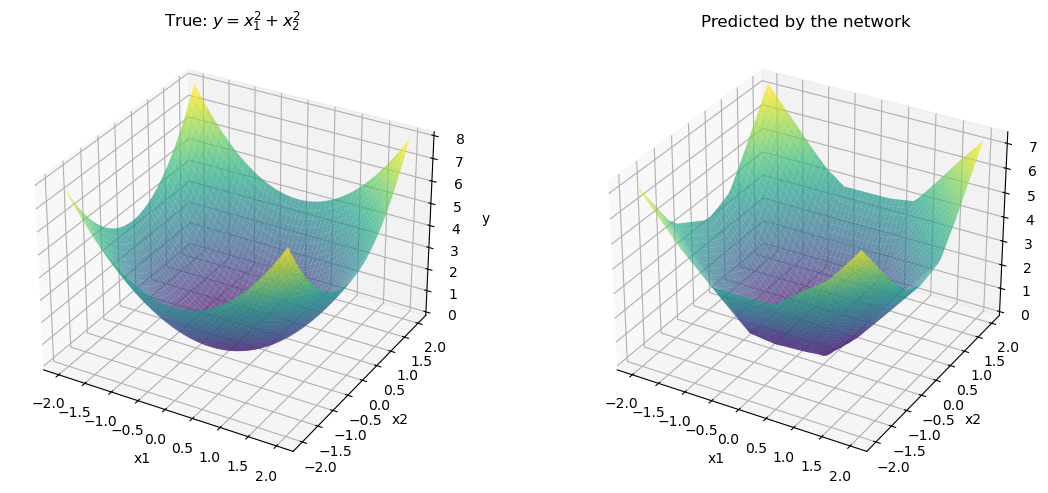

In [6]:
# Predict on a grid
grid = np.linspace(-2, 2, 50)
X1g, X2g = np.meshgrid(grid, grid)
X_grid = np.stack([X1g.ravel(), X2g.ravel()], axis=1)

model.eval()
with torch.no_grad():
    Y_grid_pred = model(torch.FloatTensor(X_grid)).numpy().reshape(X1g.shape)

Y_grid_true = X1g**2 + X2g**2

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1g, X2g, Y_grid_true, cmap='viridis', alpha=0.7)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('y')
ax1.set_title('True: $y = x_1^2 + x_2^2$')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X1g, X2g, Y_grid_pred, cmap='viridis', alpha=0.7)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('y')
ax2.set_title('Predicted by the network')

plt.tight_layout()
plt.show()

## 7. Exercises

1. **Change the network architecture:** Try adding more hidden layers or changing the number of neurons. Does the approximation improve?
2. **Reduce training data:** Use only 100 samples instead of 500. How does this affect the predictions?
3. **Try a harder function:** Replace $y = x_1^2 + x_2^2$ with $y = \sin(x_1) \cdot \cos(x_2)$. Does the network still learn it well?
4. **Compare loss functions and activation functions:** These are the key differences between classification and regression networks, as discussed in the lecture. In the next lecture, we will study them in detail.